In [1]:
# Block 1: Setup & Imports
!pip install optuna seaborn scikit-learn -q

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# Set random seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [2]:
!pip install torch
!pip install optuna seaborn scikit-learn -q


In [3]:
import pandas as pd

for i in range(6):
    try:
        df = pd.read_csv(f"content/x{i}_csi.csv", nrows=1)
        print(f"--- x{i}_csi.csv Columns ---")
        print([c for c in df.columns])
    except Exception as e:
        print(f"Could not read x{i}_csi.csv: {e}")

--- x0_csi.csv Columns ---
['host_epoch', 't_rel', 'esp_local_timestamp_us', 'seq', 'mac', 'rssi', 'noise_floor', 'rate', 'mcs', 'bandwidth', 'channel', 'secondary_channel', 'sig_len', 'num_subcarriers', 'amplitude_json', 'phase_json', 'x_label', 'presence_label', 'session_id']
--- x1_csi.csv Columns ---
['host_epoch', 't_rel', 'esp_local_timestamp_us', 'seq', 'mac', 'rssi', 'noise_floor', 'rate', 'mcs', 'bandwidth', 'channel', 'secondary_channel', 'sig_len', 'num_subcarriers', 'amplitude_json', 'phase_json', 'x_label', 'presence_label', 'session_id']
--- x2_csi.csv Columns ---
['host_epoch', 't_rel', 'esp_local_timestamp_us', 'seq', 'mac', 'rssi', 'noise_floor', 'rate', 'mcs', 'bandwidth', 'channel', 'secondary_channel', 'sig_len', 'num_subcarriers', 'amplitude_json', 'phase_json', 'x_label', 'presence_label', 'session_id']
--- x3_csi.csv Columns ---
['host_epoch', 't_rel', 'esp_local_timestamp_us', 'seq', 'mac', 'rssi', 'noise_floor', 'rate', 'mcs', 'bandwidth', 'channel', 'secondary

In [4]:
# Block 2: Corrected Preprocessing Engine for Corrupted/Fragmented CSVs

import os
import json
import re
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler


EXPECTED_COLUMNS = [
    'host_epoch', 't_rel', 'esp_local_timestamp_us', 'seq', 'mac', 'rssi',
    'noise_floor', 'rate', 'mcs', 'bandwidth', 'channel', 'secondary_channel',
    'sig_len', 'num_subcarriers', 'amplitude_json', 'phase_json',
    'x_label', 'presence_label', 'session_id'
]


def sanitize_phase(phase_array):
    """Applies linear unwrapping and phase slope correction to remove CFO/STO offsets."""

    sanitized = np.zeros_like(phase_array)

    if phase_array.size == 0:
        return sanitized

    num_subcarriers = phase_array.shape[1]
    k = np.arange(num_subcarriers)

    for i in range(len(phase_array)):
        unwrapped = np.unwrap(phase_array[i])
        slope = (unwrapped[-1] - unwrapped[0]) / (num_subcarriers - 1)
        offset = np.mean(unwrapped)

        sanitized[i] = unwrapped - (slope * k) - offset

    return sanitized


def parse_csi_file(filepath):
    """Dynamically parses both normal CSVs and malformed CSVs with unquoted JSON arrays."""

    amplitudes = []
    phases = []

    if not os.path.exists(filepath):
        return np.array([]), np.array([])

    with open(filepath, 'r') as f:
        first_line = f.readline().strip()

        has_header = (
            'host_epoch' in first_line
            or 'amplitude_json' in first_line
        )

        # We already consumed the first line above.
        # If it was a header, continue reading from the next line.
        for line in f:
            line = line.strip()

            if not line:
                continue

            # Find JSON-like bracketed arrays in the line (non-greedy)
            brackets = re.findall(r'\[.*?\]', line)

            if len(brackets) >= 2:
                try:
                    amp = json.loads(brackets[0])
                    phase = json.loads(brackets[1])

                    # Basic validation:
                    # amplitude and phase must have the same length
                    if len(amp) == len(phase) and len(amp) > 0:
                        amplitudes.append(amp)
                        phases.append(phase)

                except Exception:
                    continue

    return np.array(amplitudes), np.array(phases)


def load_and_preprocess_dataset(data_dir="content"):

    files = {
        0: "x0_csi.csv",
        1: "x1_csi.csv",
        2: "x2_csi.csv",
        3: "x3_csi.csv",
        4: "x4_csi.csv",
        5: "x5_csi.csv"
    }

    features_list = []
    labels_list = []

    bg_baseline = None

    for label, filename in files.items():

        filepath = os.path.join(data_dir, filename)

        amp, phase = parse_csi_file(filepath)

        if amp.size == 0:
            print(f"No valid packets found in {filepath}; skipping.")
            continue

        phase_clean = sanitize_phase(phase)

        # Combine amplitude and cleaned phase features
        combined = np.hstack([amp, phase_clean])

        # Use label 0 as background baseline
        if label == 0:
            bg_baseline = np.mean(combined, axis=0)

        # Subtract background baseline
        if bg_baseline is not None:
            combined = combined - bg_baseline

        features_list.append(combined)
        labels_list.append(
            np.full(len(combined), label)
        )

    if len(features_list) == 0:
        print("No data found in any input files. Returning empty arrays.")
        return np.array([]), np.array([]), None

    X_raw = np.vstack(features_list)
    y_raw = np.concatenate(labels_list)

    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)

    return X_scaled, y_raw, scaler


# Execute processing and ensure scaler is global
X_scaled, y_raw, scaler = load_and_preprocess_dataset(data_dir="content")

print("Preprocessing completed.")
print("X_scaled shape:", X_scaled.shape)
print("y_raw shape:", y_raw.shape)

Preprocessing completed.
X_scaled shape: (363054, 128)
y_raw shape: (363054,)


In [5]:
# Block 3: Sliding Window Creation & PyTorch Dataset

def create_sliding_windows(X, y, window_size=30, stride=10):
    """Transforms 2D tabular data into temporal 3D sequences (Samples, Sequence_Length, Features)."""
    X_seq, y_seq = [], []
    for i in range(0, len(X) - window_size + 1, stride):
        window_x = X[i : i + window_size]
        window_y = y[i + window_size - 1] # Label assigned to end of window

        # Only retain window if all samples share the same label
        if len(set(y[i : i + window_size])) == 1:
            X_seq.append(window_x)
            y_seq.append(window_y)

    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.int64)

# Generate sequences
WINDOW_SIZE = 30
STRIDE = 10
X_seq, y_seq = create_sliding_windows(X_scaled, y_raw, window_size=WINDOW_SIZE, stride=STRIDE)

print(f"Sequence Data Shape: {X_seq.shape}") # (Samples, Window_Size, 128)

# Train-Validation-Test Split (70% Train, 15% Val, 15% Test)
X_train, X_temp, y_train, y_temp = train_test_split(X_seq, y_seq, test_size=0.30, random_state=SEED, stratify=y_seq)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

# Custom PyTorch Dataset
class CSIDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# DataLoaders
BATCH_SIZE = 64
train_loader = DataLoader(CSIDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(CSIDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(CSIDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

Sequence Data Shape: (36289, 30, 128)


In [6]:
# Block 4: Model Definition

class CNN1D_BiLSTM(nn.Module):
    def __init__(self, input_features=128, num_classes=6, lstm_hidden=128, lstm_layers=2, dropout=0.3):
        super(CNN1D_BiLSTM, self).__init__()
        
        # 1D-CNN Block for Spatial Feature Extraction across subcarriers
        self.cnn = nn.Sequential(
            # Input: (Batch, Features=128, Window_Size=30)
            nn.Conv1d(in_channels=input_features, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=1),
            
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        # BiLSTM Block for Temporal Sequence Modeling
        self.bilstm = nn.LSTM(
            input_size=128,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0
        )
        
        # Fully Connected Output Head
        self.fc = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )
        
    def forward(self, x):
        # x shape: (Batch, Window_Size, Features) -> Permute for 1D-CNN: (Batch, Features, Window_Size)
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        
        # Permute back for LSTM: (Batch, Sequence_Length, CNN_Channels)
        x = x.permute(0, 2, 1)
        
        # BiLSTM Layer
        lstm_out, _ = self.bilstm(x)
        
        # Take feature representation from the final time step
        final_timestep = lstm_out[:, -1, :]
        
        # Classification
        logits = self.fc(final_timestep)
        return logits

# Initialize Model
model = CNN1D_BiLSTM(input_features=128, num_classes=6).to(device)
print(model)

CNN1D_BiLSTM(
  (cnn): Sequential(
    (0): Conv1d(128, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=1, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
  )
  (bilstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=6, bias=True)
  )
)


In [ ]:
# Block 5: Training Engine

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.01585, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

EPOCHS = 50
best_val_loss = float('inf')
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(1, EPOCHS + 1):
    # Training Phase
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * len(y_batch)
        _, preds = torch.max(outputs, 1)
        correct += (preds == y_batch).sum().item()
        total += len(y_batch)
        
    train_loss = running_loss / total
    train_acc = correct / total
    
    # Validation Phase
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            val_running_loss += loss.item() * len(y_batch)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == y_batch).sum().item()
            val_total += len(y_batch)
            
    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total
    
    scheduler.step(val_loss)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    # Checkpoint model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_csi_model.pth')
        
    print(f"Epoch {epoch:02d}/{EPOCHS:02d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

Epoch 01/30 | Train Loss: 1.2957 | Train Acc: 35.98% | Val Loss: 1.0913 | Val Acc: 46.65%


KeyboardInterrupt: 

--- Test Set Performance ---
              precision    recall  f1-score   support

           0     0.7516    0.9328    0.8324       908
           1     0.9864    0.8024    0.8850       906
           2     0.7729    0.8834    0.8244       909
           3     1.0000    0.9912    0.9956       908
           4     0.8215    0.5634    0.6684       907
           5     0.7920    0.8907    0.8384       906

    accuracy                         0.8440      5444
   macro avg     0.8541    0.8440    0.8407      5444
weighted avg     0.8540    0.8440    0.8407      5444



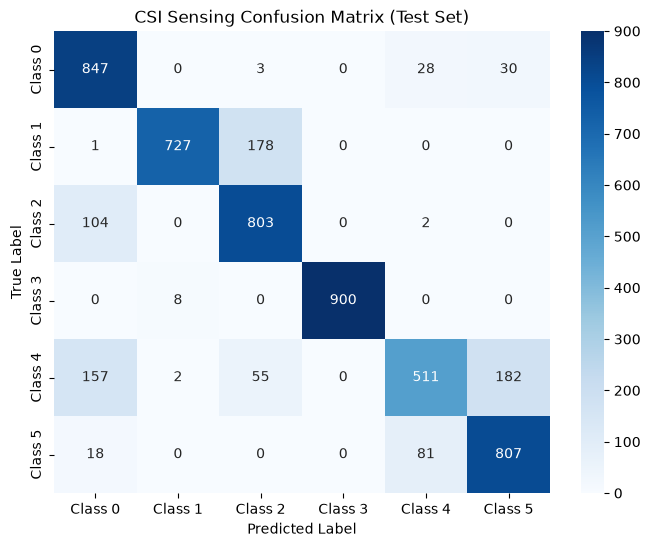

In [ ]:
# Block 6: Test Set Evaluation
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# Print Classification Report
print("--- Test Set Performance ---")
print(classification_report(all_labels, all_preds, digits=4))

# Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"Class {i}" for i in range(6)],
            yticklabels=[f"Class {i}" for i in range(6)])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('CSI Sensing Confusion Matrix (Test Set)')
plt.show()

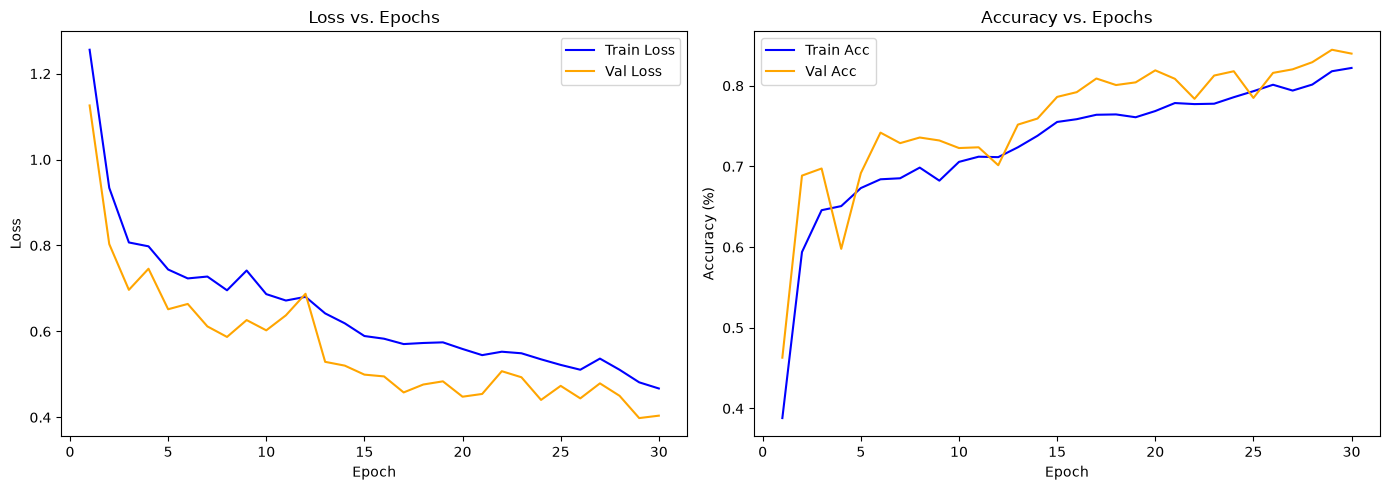

In [ ]:
# Block 7: Plot Training Metrics
epochs = range(1, len(train_losses) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss Plot
ax1.plot(epochs, train_losses, label='Train Loss', color='blue')
ax1.plot(epochs, val_losses, label='Val Loss', color='orange')
ax1.set_title('Loss vs. Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# Accuracy Plot
ax2.plot(epochs, train_accs, label='Train Acc', color='blue')
ax2.plot(epochs, val_accs, label='Val Acc', color='orange')
ax2.set_title('Accuracy vs. Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model.eval()
y_true = []
y_pred_continuous = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)

        # Convert logits to probabilities
        probs = torch.softmax(outputs, dim=1)

        # Calculate continuous expected point: sum(class_index * probability)
        class_indices = (
            torch.arange(outputs.size(1), dtype=torch.float32)
            .unsqueeze(0)
            .to(device)
        )
        expected_values = torch.sum(probs * class_indices, dim=1)

        y_true.extend(y_batch.numpy())
        y_pred_continuous.extend(expected_values.cpu().numpy())

y_true = np.array(y_true)
y_pred_continuous = np.array(y_pred_continuous)

# Compute standard regression metrics
mae = mean_absolute_error(y_true, y_pred_continuous)
mse = mean_squared_error(y_true, y_pred_continuous)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred_continuous)

print("=== Offline Dataset Signal Regression Metrics ===")
print(f"Mean Absolute Error (MAE)    : {mae:.4f}")
print(f"Mean Squared Error (MSE)     : {mse:.4f}")
print(f"Root Mean Square Error (RMSE): {rmse:.4f}")
print(f"R-squared Score (R²)         : {r2:.4f}")

=== Offline Dataset Signal Regression Metrics ===
Mean Absolute Error (MAE)    : 0.4474
Mean Squared Error (MSE)     : 0.7103
Root Mean Square Error (RMSE): 0.8428
R-squared Score (R²)         : 0.7564


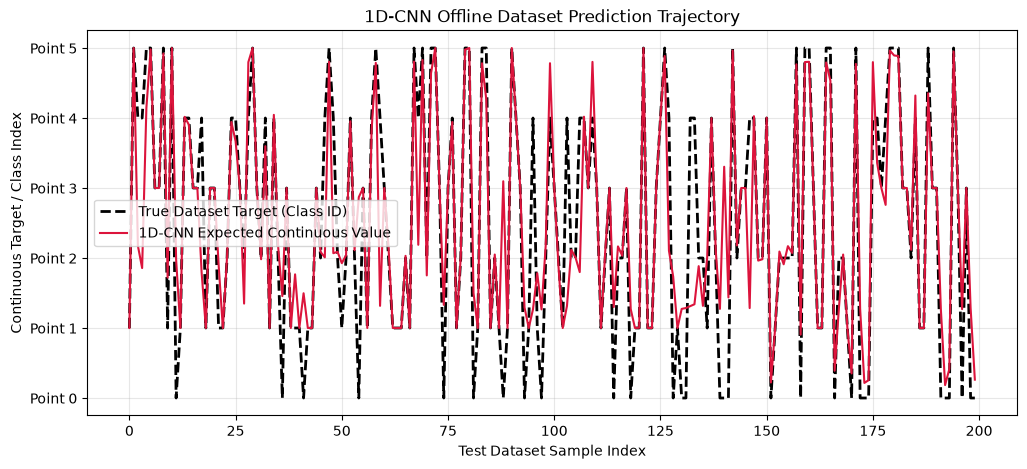

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot a slice of 200 consecutive test dataset samples
sample_window = 200
plt.plot(
    y_true[:sample_window],
    label="True Dataset Target (Class ID)",
    color="black",
    linewidth=2,
    linestyle="--",
)
plt.plot(
    y_pred_continuous[:sample_window],
    label="1D-CNN Expected Continuous Value",
    color="crimson",
    linewidth=1.5,
)

plt.title("1D-CNN Offline Dataset Prediction Trajectory")
plt.xlabel("Test Dataset Sample Index")
plt.ylabel("Continuous Target / Class Index")
plt.yticks(range(6), labels=[f"Point {i}" for i in range(6)])
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()